In [144]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import astropy.units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.stats import sigma_clipped_stats

from photutils.detection import DAOStarFinder
from photutils.aperture import SkyCircularAperture, CircularAperture, aperture_photometry

Text(0.5, 1.0, 'SNR Master Image')

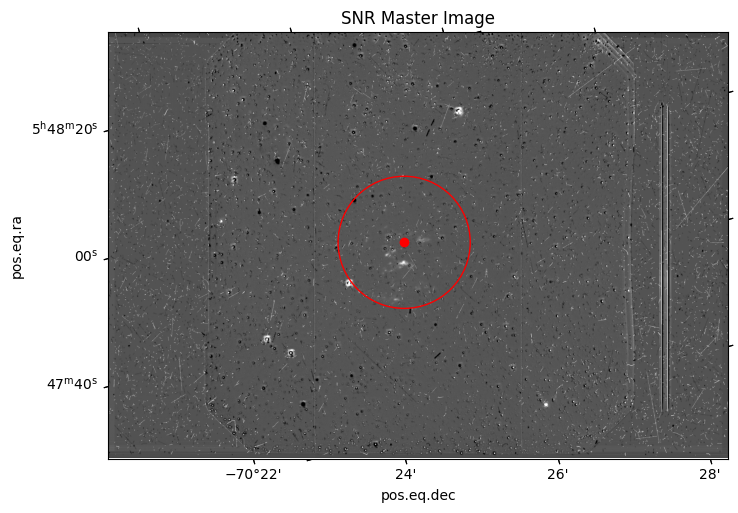

In [145]:
hdu = fits.open("subtracted_flux.fits")
image = hdu[0].data * u.erg / (u.s * u.cm**2)

wcs_hdul = fits.open("images/SNR_OIII.fits")
wcs = WCS(wcs_hdul["SCI"].header)

snr = SkyCoord("05h47m50s", "-70d24m45s", frame="icrs")

sky_aperture = SkyCircularAperture(snr, r=54*u.arcsec)
pixel_aperture = sky_aperture.to_pixel(wcs)


fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

ax.scatter(snr.ra, snr.dec, color="r", transform=ax.get_transform("world"))
pixel_aperture.plot(ax=ax, color="r")
ax.imshow(image, origin="lower", cmap="gray", vmin=np.nanpercentile(image.value, .5), vmax=np.nanpercentile(image.value, 99.5))
plt.title("SNR Master Image")

In [146]:
phot_table = aperture_photometry(image, pixel_aperture)
print(phot_table)

area = pixel_aperture.area

mean, median, std = sigma_clipped_stats(image[1000:1500, 1500:2000])
background_per_pixel = median

background_flux = background_per_pixel * area
net_flux = phot_table["aperture_sum"][0] - background_flux

print("Aperture area:", area)
print("Raw aperture flux:", phot_table["aperture_sum"][0])
print("Aperture background:", background_flux)
print("Net flux:", net_flux)
print(net_flux/background_flux)

 id      x_center           y_center          aperture_sum    
                                             erg / (s cm2)    
--- ------------------ ----------------- ---------------------
  1 1509.5777884958209 1102.691678856946 5.154260086549894e-11
Aperture area: 357096.9796618386
Raw aperture flux: 5.154260086549894e-11 erg / (s cm2)
Aperture background: 4.3383121934185086e-11 erg / (s cm2)
Net flux: 8.159478931313853e-12 erg / (s cm2)
0.18807957029215863


Text(0.5, 1.0, 'Cutout SNR')

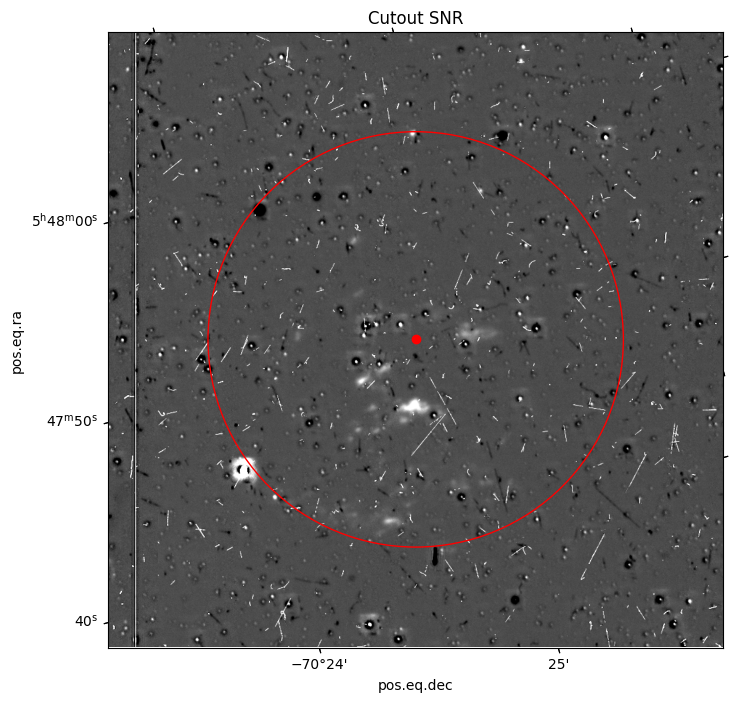

In [147]:
from astropy.nddata import Cutout2D

cutout = Cutout2D(image,position=snr, size=160 * u.arcsec, wcs=wcs)
cutout_img = cutout.data
cut_wcs = cutout.wcs

snr = SkyCoord("05h47m50s", "-70d24m45s", frame="icrs")
sky_aperture = SkyCircularAperture(snr, r=54*u.arcsec)
cutout_aperture = sky_aperture.to_pixel(cut_wcs)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=cut_wcs)

ax.scatter(snr.ra, snr.dec, color="r", transform=ax.get_transform("world"))
cutout_aperture.plot(ax=ax, color="r")
ax.imshow(cutout_img, origin="lower", cmap="gray", vmin=np.nanpercentile(cutout_img.value, .5), vmax=np.nanpercentile(cutout_img.value, 99.5))
plt.title("Cutout SNR")

In [148]:
# now mask the detected stars and calculate again

daofind = DAOStarFinder(fwhm=5.0, threshold=3 * std)
sources = daofind(cutout_img - median)

sources

id,x_centroid,y_centroid,sharpness,roundness1,roundness2,n_pixels,peak,flux,mag,daofind_mag
,,,,,,,erg / (s cm2),erg / (s cm2),,
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
1,307.97624595007653,1.5358515523736354,0.7209405792470933,0.027630377560853958,-0.012247701617378131,49,3.6237392972519053e-16,2.394577176722721e-15,36.55193,-1.534914982627718
2,991.9229543440259,1.411650322611988,0.756833093423629,-0.4814748466014862,-0.04348535731824626,49,5.5262606353545e-15,3.9016844768056946e-14,33.52187,-4.471183202102989
3,417.70515350767596,1.9002840133367729,0.8346294386399293,0.06310141831636429,-0.6236200096323711,49,4.076617532720915e-15,2.315464511207406e-14,34.088406,-4.067203548185251
4,839.9809027719643,3.3492072370407593,0.6419003396930428,-0.6020511984825134,-0.08310922287593298,49,1.5064576258124298e-16,1.227470701612636e-15,37.277473,-0.671646121963348
5,875.2017283907959,2.6204224025159837,0.49912963537876687,-0.303457111120224,0.17455156932263913,49,9.906235606596254e-16,1.1013137626793464e-14,34.89522,-2.8585409823320287
6,264.67333855143266,5.317484996573017,0.39700340514768623,0.04252738133072853,0.40152484374206915,49,1.8379947916972355e-16,1.6827195705427741e-15,36.93497,-1.2679229542013855
7,235.89350124083404,6.837714836889596,0.43432954378162497,0.1408294141292572,-0.11797556742288491,49,1.4336562027871067e-16,2.875655044829958e-15,36.353157,-0.587084405089721
8,695.3847693022535,9.988818388745978,0.4394553849015183,-0.391551673412323,-0.2553006831708104,49,3.914245128380529e-18,-5.03100978845733e-15,nan,-0.790253913323563


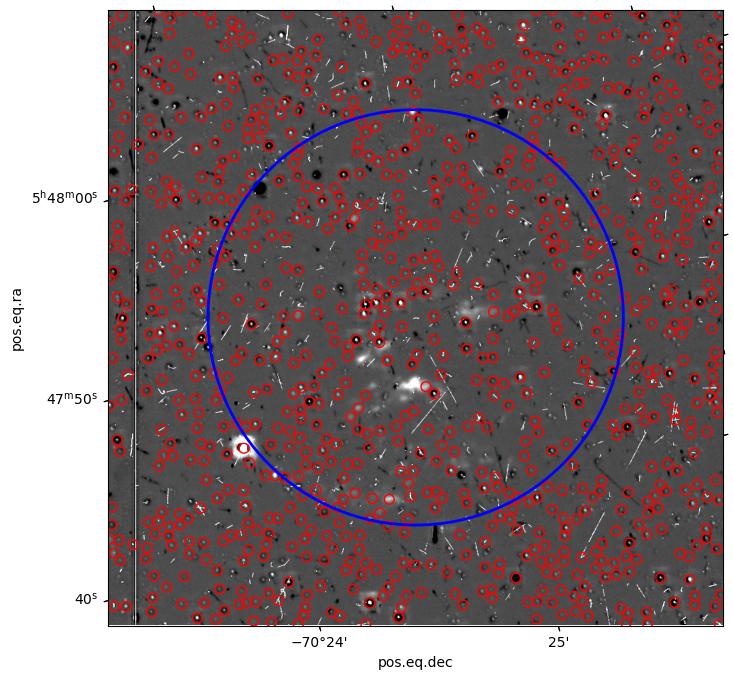

In [149]:
# detect stars within aperture
data = cutout.data.value
positions = np.transpose((sources["xcentroid"],sources["ycentroid"]))

source_apertures = CircularAperture(positions, r=8)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=cutout.wcs)

ax.imshow(data, origin="lower", cmap="gray", vmin=np.nanpercentile(data, 0.5), vmax=np.nanpercentile(data, 99.5))

source_apertures.plot(ax=ax, color="red", lw=1)

snr_aperture = sky_aperture.to_pixel(cutout.wcs)
snr_aperture.plot(ax=ax, color="blue", lw=2)

plt.show()

In [150]:
# mask sources

mask_radius = 8

y2, x2 = np.indices(cutout.data.shape)

mask = np.zeros(cutout.data.shape, dtype=bool)

for x, y in zip(sources['x_centroid'], sources['y_centroid']):
    mask |= (x2 - x)**2 + (y2 - y)**2 <= mask_radius**2

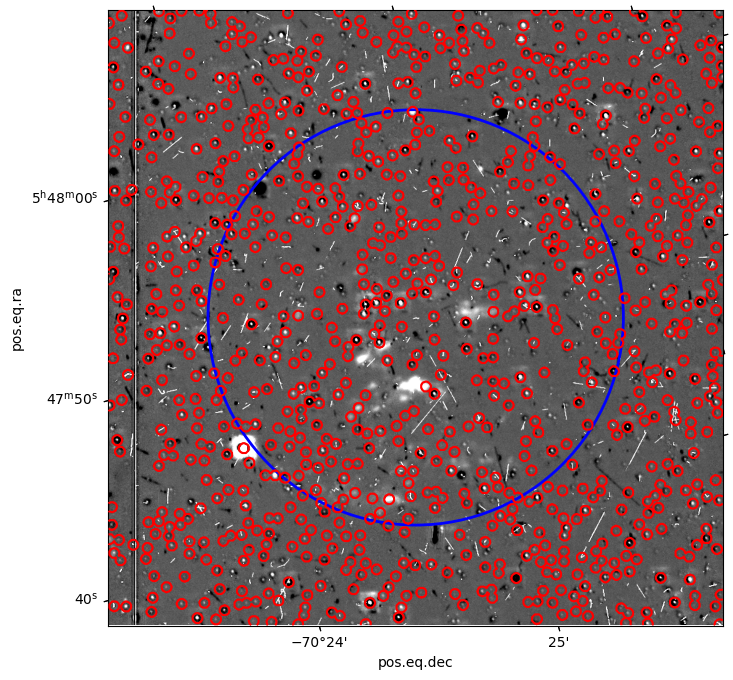

In [151]:
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=cutout.wcs)

ax.imshow(cutout.data.value, origin="lower", cmap="gray",
           vmin=np.nanpercentile(cutout.data.value, 1),
           vmax=np.nanpercentile(cutout.data.value, 99))

ax.contour(mask, levels=[0.5], colors="red")
snr_aperture = sky_aperture.to_pixel(cutout.wcs)
snr_aperture.plot(ax=ax, color="blue", lw=2)
plt.show()

In [152]:
phot_table = aperture_photometry( cutout.data, cutout_aperture,mask=mask)
# print(phot_table)

area = cutout_aperture.area

mean, median, std = sigma_clipped_stats(image[1000:1500, 1500:2000])
background_per_pixel = median

background_flux = background_per_pixel * area
net_flux = phot_table["aperture_sum"][0] - background_flux

print("Aperture area:", area)
print("Raw aperture flux:", phot_table["aperture_sum"][0])
print("Aperture background:", background_flux)
print("Net flux:", net_flux)


print(net_flux/background_flux)

Aperture area: 357096.9796618386
Raw aperture flux: 4.355001876771697e-11 erg / (s cm2)
Aperture background: 4.3383121934185086e-11 erg / (s cm2)
Net flux: 1.6689683353188234e-13 erg / (s cm2)
0.0038470452584089105


In [153]:
fits.writeto("roi_mask.fits", cutout.data.value, overwrite=True)